In [1]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_boxes.jl")
using PyPlot
using Statistics
using JLD2
using OrdinaryDiffEq

### Define the system

In [2]:
# Parameters
N = 30
r = 100
sat = [0:5:60;]
n0 = 1279

# Constants
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
γ = 32.7e6 # In Hz
@load "op_list/op_list_$N.jdl2" op_list

# Rabi frequency
Ω_RO = γ.*sqrt.(sat/2)

# Quantization axis along z
e = [0, 0, 1.]

# Normalisation
d0_lb = d0_lb / λ
Ω_RO = Ω_RO / γ
γ = 1.

t_end = 1e2

window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution

0.0%┣                                              ┫ 0/13 [00:01<00:-18, -1s/it]
7.7%┣███▎                                       ┫ 1/13 [00:03<Inf:Inf, InfGs/it]
15.4%┣███████▎                                       ┫ 2/13 [00:03<00:35, 3s/it]
23.1%┣██████████▉                                    ┫ 3/13 [00:03<00:16, 2s/it]
30.8%┣██████████████▌                                ┫ 4/13 [00:03<00:10, 1s/it]
38.5%┣██████████████████                             ┫ 5/13 [00:03<00:07, 1it/s]
46.2%┣█████████████████████▊                         ┫ 6/13 [00:03<00:05, 1it/s]
53.8%┣█████████████████████████▎                     ┫ 7/13 [00:04<00:04, 2it/s]
61.5%┣█████████████████████████████                  ┫ 8/13 [00:04<00:03, 2it/s]
69.2%┣████████████████████████████████▌              ┫ 9/13 [00:04<00:02, 2it/s]
76.9%┣███████████████████████████████████▍          ┫ 10/13 [00:04<00:01, 2it/s]
84.6%┣███████████████████████████████████████       ┫ 11/13 [00:04<00:01, 3it/s]
92.3%┣██████████████████████

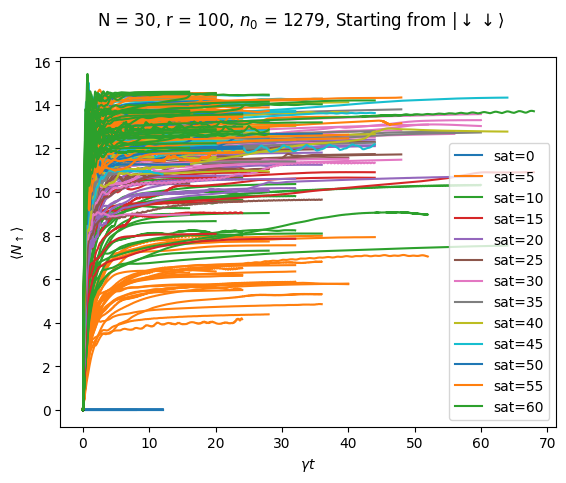

In [3]:
close("all")
fig, ax = subplots() 

list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    @load "solutions/sol_N_$(N)_r_$(r)_sat_$(s)_n0_$n0.jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t)
        if j ∉ nbr_error
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="sat=$(s)")
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

0.0%┣                                               ┫ 0/13 [00:00<00:00, -0s/it]
38.5%┣█████████████████▊                            ┫ 5/13 [00:00<00:00, 63it/s]
53.8%┣████████████████████████▊                     ┫ 7/13 [00:00<00:00, 52it/s]
76.9%┣██████████████████████████████████▋          ┫ 10/13 [00:00<00:00, 51it/s]
100.0%┣████████████████████████████████████████████┫ 13/13 [00:00<00:00, 48it/s]
100.0%┣████████████████████████████████████████████┫ 13/13 [00:00<00:00, 47it/s]


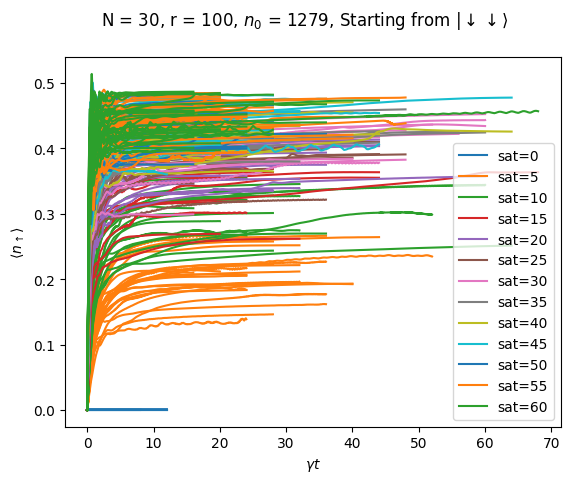

In [4]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="sat=$(s)")
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

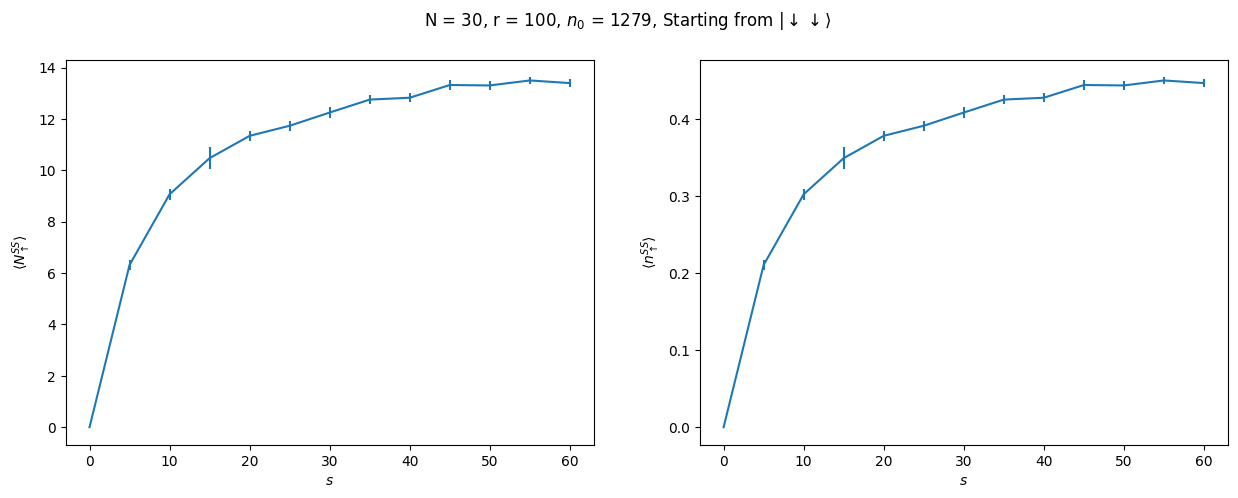

In [5]:
# For sat = 0, only throws errors as density to close from 0 --> remove the errors 
if 0 ∈ sat
    idx = findall(sat .== 0)[1]
    for i in 1:length(nbr_error_t_N[idx])
        if maximum(abs.(popup_t_N[idx][nbr_error_t_N[idx][i]])) < 10
            nbr_error_t_N[idx][i] = 0 # Physical solution
        end
    end
end

mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j ∉ nbr_error_t_N[i]] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j∉nbr_error_t_N[i]] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(sat, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(sat, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")

pygui(false); gcf();
# pygui(true); show()

# Compute the total intensity (laser + $\gamma_{Gamma}/N$)

In [18]:
Itot = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            print(L)
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                for b = 1:N
                    if a == b # SE
                        Itot[i, j] += Γ_CS[a, a]*sol_SS[a]
                    end
                    if b > a # Correlated decay
                        # corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                        corr = [22*10^(floor(Int, log10(a))+1)+a, 22*10^(floor(Int, log10(b))+1)+b]
                        try
                            Itot[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                        catch
                            println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                        end
                    end
                end
            end
            Itot[i, j] /= N
        end
    end
end
Itot

0.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312514421850.28625312

13×100 Matrix{ComplexF64}:
 5.54145e-8-2.12224e-21im  0.0+0.0im  …  1.36578e-6+8.91618e-21im
    1.69369+2.66644e-17im  0.0+0.0im            0.0+0.0im
        0.0+0.0im          0.0+0.0im            0.0+0.0im
        0.0+0.0im          0.0+0.0im            0.0+0.0im
        0.0+0.0im          0.0+0.0im            0.0+0.0im
        0.0+0.0im          0.0+0.0im  …         0.0+0.0im
     4.5414+1.88638e-16im  0.0+0.0im            0.0+0.0im
        0.0+0.0im          0.0+0.0im            0.0+0.0im
        0.0+0.0im          0.0+0.0im            0.0+0.0im
    3.66387+4.16794e-17im  0.0+0.0im        5.06705+4.59321e-17im
        0.0+0.0im          0.0+0.0im  …         0.0+0.0im
        0.0+0.0im          0.0+0.0im            0.0+0.0im
        0.0+0.0im          0.0+0.0im            0.0+0.0im

In [19]:
Itot = real.(Itot)

13×100 Matrix{Float64}:
 5.54145e-8  0.0  2.31432e-6  1.52727e-6  …  0.0      1.29644e-7  1.36578e-6
 1.69369     0.0  0.0         0.951208       0.0      0.0         0.0
 0.0         0.0  0.0         1.78578        0.0      0.0         0.0
 0.0         0.0  0.0         0.0            3.20503  3.19075     0.0
 0.0         0.0  0.0         0.0            0.0      0.0         0.0
 0.0         0.0  2.64548     0.0         …  0.0      3.80414     0.0
 4.5414      0.0  0.0         0.0            0.0      0.0         0.0
 0.0         0.0  0.0         0.0            0.0      0.0         0.0
 0.0         0.0  0.0         0.0            0.0      0.0         0.0
 3.66387     0.0  0.0         0.0            0.0      0.0         5.06705
 0.0         0.0  0.0         0.0         …  4.13465  0.0         0.0
 0.0         0.0  0.0         0.0            0.0      4.74754     0.0
 0.0         0.0  0.0         4.89694        4.97264  0.0         0.0

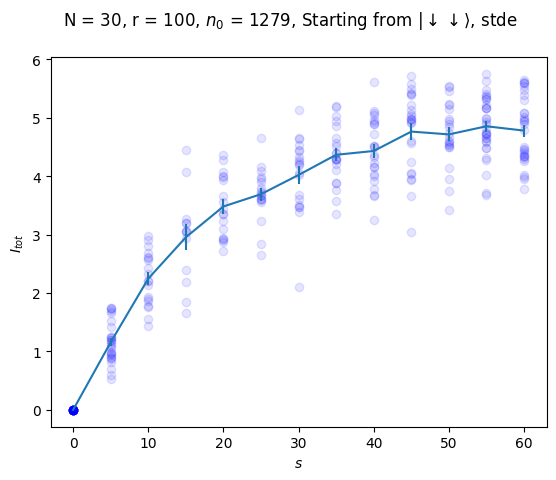

In [20]:
close("all")
fig = subplots()

errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)])

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"$I_{tot}$")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")

# pygui(true); show()
pygui(false);

In [24]:
@load "r0/r0_N_$(N)_r_1.jdl2" r0 L
L

0.2862531251442185

In [21]:
@save "Itot/Itot_N_$(N)_r_$(r)_sat_$(sat)_n0_$n0.jdl2" Itot nbr_error_t_N sat

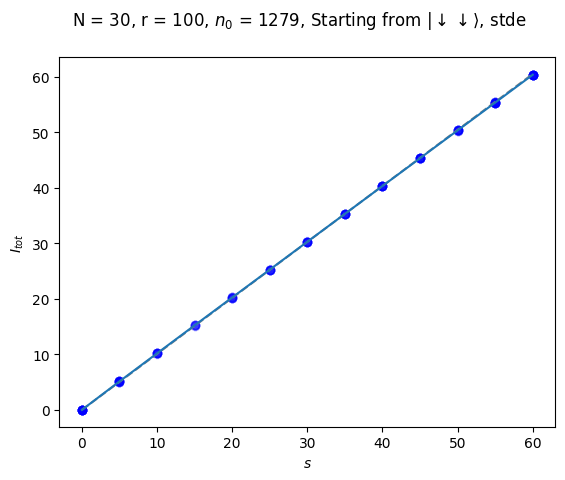

In [10]:
close("all")
fig = subplots()

errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)] .+ sat, yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)])

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j] + sat[i], alpha=0.1, color="blue")
        end
    end
end

function It(sat, Iatoms)
    return Iatoms[sat.==35]/35 .* sat
end

It_range = It(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)] .+ sat)
plot(sat, It_range, linestyle="--", color="grey", label=L"I_t")


xlabel(L"s")
ylabel(L"$I_{tot}$")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")

# pygui(true); show()
pygui(false);

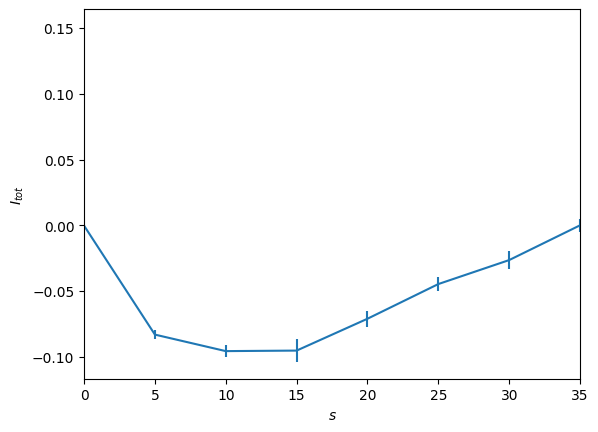

In [11]:
close("all")
fig = subplots()

errorbar(sat, It_range .- ([mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)] .+ sat), yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)])

xlabel(L"s")
ylabel(L"$I_{tot}$")

xlim(0, 35)
# pygui(true); show()
pygui(false);

# Decompose $I_{tot} = I_{SE} + I_{SR}$

In [12]:
I_SE = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                for b = 1:N
                    if a == b # SE
                        I_SE[i, j] += Γ_CS[a, a]*sol_SS[a]
                    end
                end
            end
            I_SE[i, j] /= N
        end
    end
end
I_SE = real.(I_SE)

13×100 Matrix{Float64}:
 3.90331e-7  0.0  2.45153e-6  1.56319e-6  …  0.0       1.29265e-7  1.22656e-6
 0.261005    0.0  0.0         0.193175       0.0       0.0         0.0
 0.0         0.0  0.0         0.269718       0.0       0.0         0.0
 0.0         0.0  0.0         0.0            0.366997  0.363482    0.0
 0.0         0.0  0.0         0.0            0.0       0.0         0.0
 0.0         0.0  0.32164     0.0         …  0.0       0.398748    0.0
 0.443153    0.0  0.0         0.0            0.0       0.0         0.0
 0.0         0.0  0.0         0.0            0.0       0.0         0.0
 0.0         0.0  0.0         0.0            0.0       0.0         0.0
 0.394414    0.0  0.0         0.0            0.0       0.0         0.455939
 0.0         0.0  0.0         0.0         …  0.416414  0.0         0.0
 0.0         0.0  0.0         0.0            0.0       0.441035    0.0
 0.0         0.0  0.0         0.455861       0.457465  0.0         0.0

In [13]:
I_SR = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)

    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                for b = 1:N
                    if b > a # Correlated decay
                        corr = [22*10^(floor(Int, log10(a))+1)+a, 22*10^(floor(Int, log10(b))+1)+b]
                        try
                            I_SR[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                        catch
                            println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                        end
                    end
                end
            end
            I_SR[i, j] /= N
        end
    end
end
I_SR = real.(I_SR)

13×100 Matrix{Float64}:
 -3.34917e-7  0.0  -1.37206e-7  …  0.0      3.79162e-10  1.39225e-7
  1.43268     0.0   0.0            0.0      0.0          0.0
  0.0         0.0   0.0            0.0      0.0          0.0
  0.0         0.0   0.0            2.83803  2.82727      0.0
  0.0         0.0   0.0            0.0      0.0          0.0
  0.0         0.0   2.32384     …  0.0      3.40539      0.0
  4.09824     0.0   0.0            0.0      0.0          0.0
  0.0         0.0   0.0            0.0      0.0          0.0
  0.0         0.0   0.0            0.0      0.0          0.0
  3.26946     0.0   0.0            0.0      0.0          4.61111
  0.0         0.0   0.0         …  3.71823  0.0          0.0
  0.0         0.0   0.0            0.0      4.3065       0.0
  0.0         0.0   0.0            4.51517  0.0          0.0

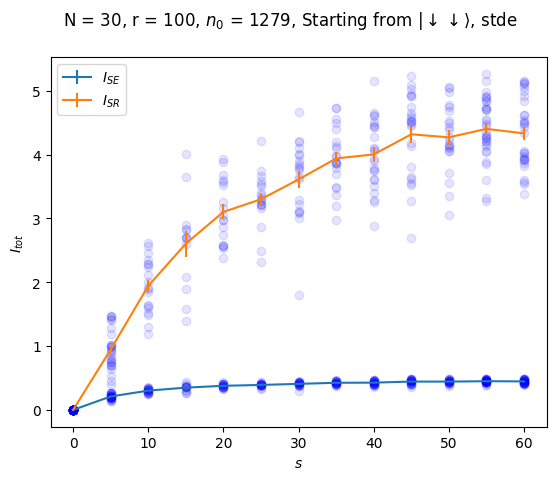

In [14]:
close("all")
fig = subplots()

errorbar(sat, [mean([I_SE[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([I_SE[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)], label=L"I_{SE}")
errorbar(sat, [mean([I_SR[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([I_SR[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)], label=L"I_{SR}")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], I_SE[i, j], alpha=0.1, color="blue")
            scatter(sat[i], I_SR[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"$I_{tot}$")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()
# pygui(true); show()
pygui(false);

# Adding the transmitted light

In [15]:
I_laser = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            if length(sol_t_N[i][j][end]) > 1 # If the full solution was saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                I_laser[i, j] += 2*Ω_RO[i]*sol_SS[findfirst(x->x==[21*10^(floor(Int, log10(a))+1)+a], op_list)] #σ- =conj(σ+) and we take the real part afterwards
            end
            I_laser[i, j] /= N
        end
    end
end
I_laser = real.(I_laser)

13×100 Matrix{Float64}:
 0.0       0.0  0.0       0.0       0.0       …  0.0       0.0      0.0
 0.125145  0.0  0.0       0.116597  0.0          0.0       0.0      0.0
 0.0       0.0  0.0       0.112706  0.0          0.0       0.0      0.0
 0.0       0.0  0.0       0.0       0.0          0.146042  0.1678   0.0
 0.0       0.0  0.0       0.0       0.0          0.0       0.0      0.0
 0.0       0.0  0.195445  0.0       0.147659  …  0.0       0.16906  0.0
 0.193505  0.0  0.0       0.0       0.0          0.0       0.0      0.0
 0.0       0.0  0.0       0.0       0.0          0.0       0.0      0.0
 0.0       0.0  0.0       0.0       0.0          0.0       0.0      0.0
 0.332369  0.0  0.0       0.0       0.0          0.0       0.0      0.220886
 0.0       0.0  0.0       0.0       0.0       …  0.276345  0.0      0.0
 0.0       0.0  0.0       0.0       0.0          0.0       0.27439  0.0
 0.0       0.0  0.0       0.290522  0.0          0.294665  0.0      0.0

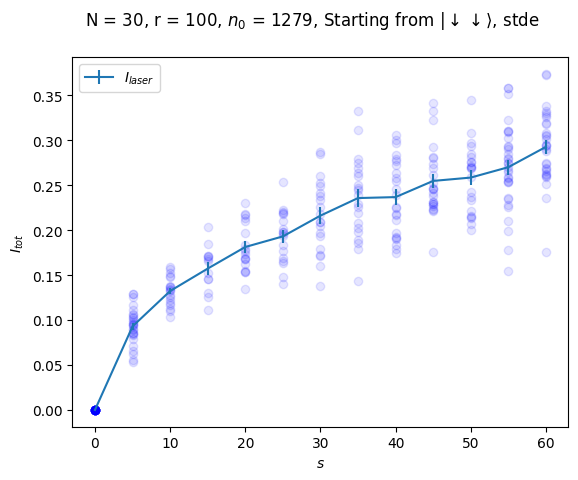

In [16]:
close("all")
fig = subplots()

errorbar(sat, [mean([I_laser[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([I_laser[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)], label=L"I_{laser}")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], I_laser[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"$I_{tot}$")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()
# pygui(true); show()
pygui(false);

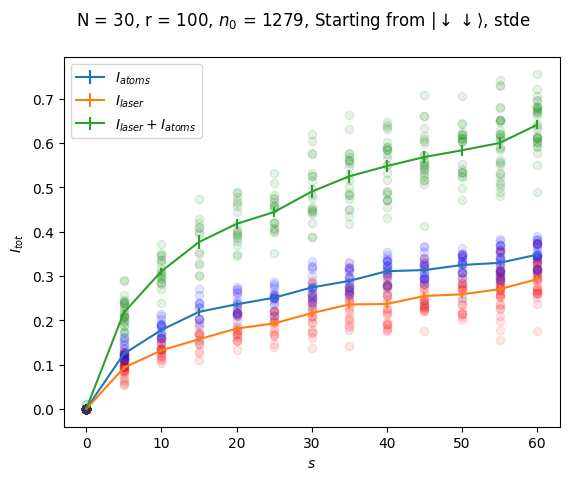

In [17]:
close("all")
fig = subplots()

errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)], label=L"I_{atoms}")
errorbar(sat, [mean([I_laser[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([I_laser[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)], label=L"I_{laser}")
errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)] .+ [mean([I_laser[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([Itot[i, j] + I_laser[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)], label=L"I_{laser}+I_{atoms}")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], I_laser[i, j], alpha=0.1, color="red")
            scatter(sat[i], Itot[i, j], alpha=0.1, color="blue")
            scatter(sat[i], Itot[i, j] + I_laser[i, j], alpha=0.1, color="green")
        end
    end
end

xlabel(L"s")
ylabel(L"$I_{tot}$")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()
# pygui(true); show()
pygui(false);
